# Unit 5 — 07: A/B Testing and Canary Deployment for Model Releases

**What you will do:** Build an `ABRouter` that splits traffic between two models, analyze the results with statistical tests, then build a `CanaryDeployment` class that gradually promotes the new model — or rolls it back.

**Why it matters:** Replacing a production model immediately is high-risk. A/B testing and canary deployments let you measure the real impact on live traffic before committing.

**How to run:** Python 3.10+. Run cells in order.

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 08 "Computing P-values and Confidence Intervals" — you learned to decide whether an observed difference is real or noise; an A/B test on live traffic is that same computation, with a rollback decision and real users attached to the answer.

---

## 📰 The Bing headline change nobody thought was worth building

In 2012 an engineer at Microsoft suggested changing how ad headlines were displayed in Bing search results. It was judged low priority and sat in the backlog for months, because nobody senior believed a small formatting change mattered. Eventually an engineer implemented it in a few days and ran it as an online controlled experiment. Revenue in the treatment arm rose by about **12%** — worth on the order of **$100 million a year**, and described by Ronny Kohavi (who ran Microsoft's experimentation platform, and later wrote *Trustworthy Online Controlled Experiments*) as the best revenue-generating idea in Bing's history.

The lesson is not "small changes can be big". It is that **the organisation's collective judgement about which ideas were valuable was wrong, and only the experiment revealed it.** Kohavi's broader finding from running that platform is the same one Booking.com reported (Unit 3, notebook 03): most ideas that experts are confident about do not produce the expected gain, and occasionally an idea nobody rated is worth a fortune. Offline evaluation cannot distinguish these cases. Live traffic can.

**What goes wrong without this lesson.** Replacing model A with model B because B scored higher on a held-out set is a bet that the test set resembles reality, that every user segment behaves like the average, and that latency does not matter. Each of those has failed publicly and expensively. A/B testing measures the bet; canary deployment limits what it costs when it is wrong.

## Section 1 — Why Not Replace Model A with Model B Immediately?

A new model may score higher on your held-out test set but still:
- Perform worse on specific user segments not well-represented in test data
- Have higher latency under production load
- Produce confident but wrong predictions on edge cases

**A/B testing** routes a fraction of live traffic to the new model and measures real outcomes side by side.  
**Canary deployment** makes the rollout gradual: 5% → 25% → 100%, with automatic rollback if metrics degrade at any step.

## Section 2 — A/B Testing Setup

In [1]:
# WHAT: train the two contenders (a weak champion A, a stronger candidate B) and
# build the ABRouter that randomly splits traffic between them.
# WHY: an A/B test needs a real difference to detect and an unbiased coin to
# assign requests — both are constructed here.
import numpy as np
import time
from typing import List, Dict, Tuple

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(42)

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model A: current production model. We deliberately under-regularize it
# (small C) so it is a genuinely WEAKER baseline (~0.82 accuracy) — this gives
# the A/B test a real difference to detect, the way an older model would.
model_a = LogisticRegression(C=0.008, max_iter=200, random_state=42)
model_a.fit(X_train, y_train)

# Model B: candidate model (RandomForest — should be better)
model_b = RandomForestClassifier(n_estimators=50, random_state=42)
model_b.fit(X_train, y_train)

print(f"Model A (LogisticRegression) test accuracy: {model_a.score(X_test, y_test):.4f}")
print(f"Model B (RandomForest)        test accuracy: {model_b.score(X_test, y_test):.4f}")


# The router IS the experiment: random assignment per request, nothing else.
class ABRouter:
    """Routes a fraction of traffic to model B; the rest goes to model A."""

    def __init__(self, model_a: object, model_b: object, b_fraction: float = 0.10):
        self.model_a = model_a
        self.model_b = model_b
        self.b_fraction = b_fraction
        self._rng = np.random.default_rng(0)

    def predict(self, X: np.ndarray) -> Tuple[int, str, float]:
        """
        Returns (prediction, model_used, confidence).
        model_used is 'A' or 'B'.
        """
        use_b = self._rng.random() < self.b_fraction
        model = self.model_b if use_b else self.model_a
        proba = model.predict_proba(X.reshape(1, -1))[0]
        prediction = int(np.argmax(proba))
        confidence = float(np.max(proba))
        model_used = "B" if use_b else "A"
        return prediction, model_used, confidence


router = ABRouter(model_a, model_b, b_fraction=0.50)
print(f"\nABRouter created: 50/50 A/B split so both arms get enough samples to compare.")

Model A (LogisticRegression) test accuracy: 0.8222
Model B (RandomForest)        test accuracy: 1.0000

ABRouter created: 50/50 A/B split so both arms get enough samples to compare.


In [2]:
# WHAT: push 1000 requests through the router, logging model used, correctness,
# confidence, and latency for each.
# WHY: this log is the experiment's raw data — the split counts confirm the
# router honored the 50/50 assignment.
# Simulate 1000 requests through the router
N_REQUESTS = 1000
request_log: List[Dict] = []

for i in range(N_REQUESTS):
    idx = rng.integers(0, len(X_test))
    X_sample = X_test[idx]
    true_label = int(y_test[idx])

    t0 = time.perf_counter()
    prediction, model_used, confidence = router.predict(X_sample)
    latency_ms = (time.perf_counter() - t0) * 1000

    request_log.append({
        "model": model_used,
        "prediction": prediction,
        "true_label": true_label,
        "correct": prediction == true_label,
        "confidence": confidence,
        "latency_ms": latency_ms,
    })

a_logs = [r for r in request_log if r["model"] == "A"]
b_logs = [r for r in request_log if r["model"] == "B"]

print(f"Total requests: {N_REQUESTS}")
print(f"  Served by Model A: {len(a_logs)}")
print(f"  Served by Model B: {len(b_logs)}")

Total requests: 1000
  Served by Model A: 527
  Served by Model B: 473


## Section 3 — Analyze A/B Results

                        Requests  Accuracy  Mean Confidence  Mean Latency (ms)  p95 Latency (ms)
Model                                                                                           
A (LogisticRegression)       527    0.8159           0.5234             0.0323            0.0439
B (RandomForest)             473    1.0000           0.9762             1.1125            1.2678


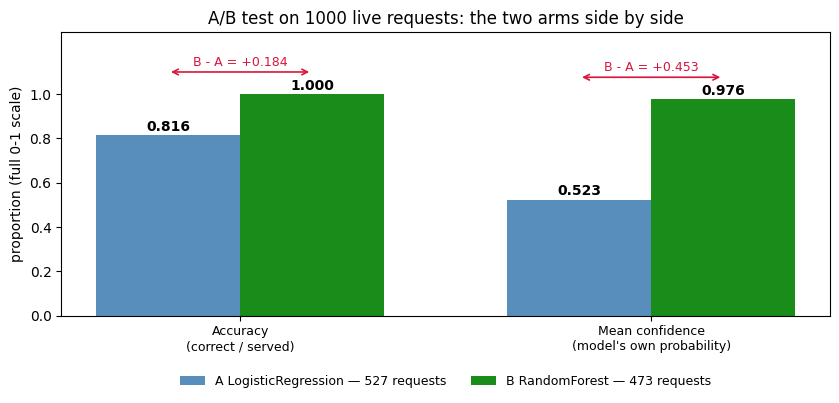

In [3]:
# WHAT: summarize each arm — accuracy, confidence, latency — in one table and chart.
# WHY: eyeballing the gap comes FIRST, but the next cell asks the essential
# question: is this difference real or just luck of the traffic split?
import pandas as pd


def summarize_logs(logs: List[Dict], label: str) -> Dict:
    accuracy = np.mean([r["correct"] for r in logs])
    mean_confidence = np.mean([r["confidence"] for r in logs])
    mean_latency = np.mean([r["latency_ms"] for r in logs])
    p95_latency = np.percentile([r["latency_ms"] for r in logs], 95)
    return {
        "Model": label,
        "Requests": len(logs),
        "Accuracy": round(accuracy, 4),
        "Mean Confidence": round(mean_confidence, 4),
        "Mean Latency (ms)": round(mean_latency, 4),
        "p95 Latency (ms)": round(p95_latency, 4),
    }


summary_a = summarize_logs(a_logs, "A (LogisticRegression)")
summary_b = summarize_logs(b_logs, "B (RandomForest)")

df_summary = pd.DataFrame([summary_a, summary_b]).set_index("Model")
print(df_summary.to_string())

# Both metrics are proportions, so they belong on ONE 0-1 axis. Zooming the axis
# to the top of the bars is the classic way to make a small gap look decisive —
# and it also hides any bar that falls below the zoomed floor.
metrics = ["Accuracy\n(correct / served)", "Mean confidence\n(model's own probability)"]
a_vals = [summary_a["Accuracy"], summary_a["Mean Confidence"]]
b_vals = [summary_b["Accuracy"], summary_b["Mean Confidence"]]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(metrics))
w = 0.35
bars_a = ax.bar(x - w / 2, a_vals, w, color="steelblue", alpha=0.9,
                label=f"A LogisticRegression — {summary_a['Requests']} requests")
bars_b = ax.bar(x + w / 2, b_vals, w, color="green", alpha=0.9,
                label=f"B RandomForest — {summary_b['Requests']} requests")
for bar_group in (bars_a, bars_b):
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
# Write the gap on the picture — it is the quantity the z-test below judges.
for i, (va, vb) in enumerate(zip(a_vals, b_vals)):
    y_bracket = max(va, vb) + 0.10          # one flat bracket above both bars
    ax.annotate("", xy=(i - w / 2, y_bracket), xytext=(i + w / 2, y_bracket),
                arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.2))
    ax.text(i, y_bracket + 0.03, f"B - A = {vb - va:+.3f}", ha="center",
            fontsize=9, color="crimson")
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim(0, 1.28)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel("proportion (full 0-1 scale)")
ax.set_title("A/B test on 1000 live requests: the two arms side by side")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2, fontsize=9,
          frameon=False)
plt.tight_layout()
plt.savefig("/tmp/ab_test_results.png", dpi=72)
plt.show()

**Read the figure.** Four bars on one honest 0-to-1 axis. On accuracy the candidate B is ahead by 0.184 — a large gap, but it rests on roughly 500 requests per arm, which is exactly what the z-test in Section 4 exists to judge. On mean confidence the gap is more than twice as wide: the incumbent A averages 0.523, barely above the middle of the axis, while B averages 0.976.

Now note where A's confidence bar ends: **below 0.7**. On a panel zoomed to 0.7-1.0 — the reflex when bars look similar — that bar falls outside the plotting area entirely and is simply not drawn, leaving one green bar and nothing to compare it to. A zoomed axis does not only exaggerate small gaps; it can delete a data point.

**What it proves.** B wins on both metrics measured here, and neither of them costs anything to serve. Section 5 puts the same two models on the axis this figure leaves out.

## Section 4 — Statistical Significance Test

Model B may look better in the A/B data, but is the difference statistically significant or just random variation? Use a two-proportion z-test to check.

In [4]:
# WHAT: run a two-proportion z-test on the two arms' accuracy.
# WHY: this is the statistics that separates 'B looks better' from 'B IS better
# at alpha=0.05' — the difference between an anecdote and a decision.
from scipy import stats as sp_stats


def two_proportion_z_test(n_a: int, correct_a: int, n_b: int, correct_b: int) -> Dict:
    """
    Two-proportion z-test: is Model B's accuracy significantly different from Model A's?
    H0: p_B == p_A
    """
    p_a = correct_a / n_a
    p_b = correct_b / n_b
    p_pool = (correct_a + correct_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
    z_stat = (p_b - p_a) / se if se > 0 else 0.0
    # Two-tailed p-value
    p_value = 2 * (1 - sp_stats.norm.cdf(abs(z_stat)))
    return {
        "accuracy_a": round(p_a, 4),
        "accuracy_b": round(p_b, 4),
        "z_statistic": round(z_stat, 4),
        "p_value": round(p_value, 6),
        "significant_at_0.05": p_value < 0.05,
    }


# Feed the test raw counts, not percentages — sample size is half the story.
n_a = len(a_logs)
correct_a = sum(r["correct"] for r in a_logs)
n_b = len(b_logs)
correct_b = sum(r["correct"] for r in b_logs)

result = two_proportion_z_test(n_a, correct_a, n_b, correct_b)

print("Two-proportion z-test results:")
for k, v in result.items():
    print(f"  {k}: {v}")

print()
# Read the verdict: significance plus DIRECTION decides promote vs keep testing.
if result["significant_at_0.05"]:
    if result["accuracy_b"] > result["accuracy_a"]:
        print("CONCLUSION: Model B is significantly BETTER than Model A at alpha=0.05.")
    else:
        print("CONCLUSION: Model B is significantly WORSE than Model A at alpha=0.05.")
else:
    print("CONCLUSION: No statistically significant difference detected.")
    print(f"  (Need more data — try n_b >= {int(n_a * 0.5)} before concluding.)")

Two-proportion z-test results:
  accuracy_a: 0.8159
  accuracy_b: 1.0
  z_statistic: 9.819
  p_value: 0.0
  significant_at_0.05: True

CONCLUSION: Model B is significantly BETTER than Model A at alpha=0.05.


## Section 5 — Canary Deployment

A canary deployment shifts traffic gradually: 5% → 10% → 25% → 50% → 100%, checking metrics at each stage. If metrics degrade, roll back.

**What to gate on:** at 5% traffic the *blended* overall accuracy is 95% old model — a bad canary barely moves it, and a good canary can't lift it. The honest gate compares the **canary slice's own accuracy** against the old model's baseline: promote while the canary is not worse (within a small margin), roll back the moment it degrades. We demonstrate both outcomes below — a good canary that gets promoted stage by stage, and a bad one that gets rolled back at the first gate.

In [5]:
# Canary deployment: gradually shift traffic to the new model, gating each
# stage on the CANARY SLICE's accuracy vs the old model's baseline.
class CanaryDeployment:
    """
    Manages a gradual rollout from old_model to new_model.
    fraction = fraction of traffic routed to new_model (0.0 to 1.0).
    """

    STAGES = [0.05, 0.10, 0.25, 0.50, 1.00]

    def __init__(self, old_model: object, new_model: object, initial_fraction: float = 0.05):
        self.old_model = old_model
        self.new_model = new_model
        self.fraction = initial_fraction
        self._stage_idx = 0
        self._rng = np.random.default_rng(7)

    # Route one request: a weighted coin decides old vs new model.
    def predict(self, X: np.ndarray) -> Tuple[int, str]:
        # Route this request to new or old model according to the traffic fraction
        use_new = self._rng.random() < self.fraction
        model = self.new_model if use_new else self.old_model
        prediction = int(model.predict(X.reshape(1, -1))[0])
        return prediction, "new" if use_new else "old"

    # Advance to the next traffic stage (5 -> 10 -> 25 -> 50 -> 100%).
    def promote(self) -> None:
        """Move to the next traffic stage."""
        self._stage_idx = min(self._stage_idx + 1, len(self.STAGES) - 1)
        self.fraction = self.STAGES[self._stage_idx]

    # Emergency exit: instantly return all traffic to the old model.
    def rollback(self) -> None:
        """Immediately route all traffic back to old model."""
        self.fraction = 0.0
        self._stage_idx = 0
        print("  ROLLED BACK: 100% traffic back to old model.")

    def status(self) -> str:
        return f"Stage {self._stage_idx}: {self.fraction*100:.0f}% new model traffic"


# Grades each stage on the canary SLICE's own accuracy, not the blended number
# — blending would hide a bad new model behind the old one's traffic share.
def evaluate_canary(
    canary: CanaryDeployment,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
    n_samples: int = 300,
) -> Dict:
    """Run n_samples requests through the canary; report blended AND per-slice accuracy."""
    logs = []
    indices = rng.integers(0, len(X_eval), size=n_samples)
    for idx in indices:
        pred, model_used = canary.predict(X_eval[idx])
        logs.append({"model": model_used, "correct": pred == int(y_eval[idx])})

    new_logs = [r for r in logs if r["model"] == "new"]
    overall_acc = float(np.mean([r["correct"] for r in logs]))
    new_acc = float(np.mean([r["correct"] for r in new_logs])) if new_logs else float("nan")
    return {"overall_accuracy": overall_acc, "new_model_accuracy": new_acc,
            "n": n_samples, "n_new": len(new_logs)}


# The full rollout loop: evaluate a stage, promote if the gate holds,
# roll back the moment the canary slice falls below the gate.
def run_canary_rollout(old_model, new_model, X_eval, y_eval, margin: float = 0.02):
    """Walk the canary through its stages, gating each on the canary slice.

    Gate: the new model's slice accuracy must stay within `margin` of the old
    model's baseline accuracy. Returns the per-stage results for plotting."""
    baseline_acc = float(old_model.score(X_eval, y_eval))
    gate = baseline_acc - margin
    print(f"Old-model baseline accuracy: {baseline_acc:.3f}  (gate: canary slice >= {gate:.3f})")
    print("-" * 76)

    canary = CanaryDeployment(old_model, new_model, initial_fraction=0.05)
    results = []
    while True:
        m = evaluate_canary(canary, X_eval, y_eval, n_samples=300)
        print(f"  {canary.status():<36} overall={m['overall_accuracy']:.3f}  "
              f"canary_slice={m['new_model_accuracy']:.3f} (n={m['n_new']})")
        results.append({"stage": canary.fraction,
                        "overall": m["overall_accuracy"],
                        "new_slice": m["new_model_accuracy"],
                        "n_new": m["n_new"]})   # how many requests the gate judged

        # Gate on the canary's OWN slice — the blend hides its quality at 5%
        if m["new_model_accuracy"] < gate:
            canary.rollback()
            break
        if canary.fraction == 1.0:
            print("  FULLY PROMOTED: new model now serves 100% of traffic.")
            break
        canary.promote()
    return results, gate


# Two runs prove both paths: promotion for a good model, rollback for a bad one.
print("Scenario 1 — GOOD canary (new model is stronger): expect stage-by-stage promotion")
stage_results, gate_line = run_canary_rollout(model_a, model_b, X_test, y_test)

print()
print("Scenario 2 — BAD canary (deploying the weak model over the strong one): expect rollback")
bad_results, bad_gate = run_canary_rollout(model_b, model_a, X_test, y_test)

Scenario 1 — GOOD canary (new model is stronger): expect stage-by-stage promotion
Old-model baseline accuracy: 0.822  (gate: canary slice >= 0.802)
----------------------------------------------------------------------------
  Stage 0: 5% new model traffic        overall=0.837  canary_slice=1.000 (n=17)
  Stage 1: 10% new model traffic       overall=0.857  canary_slice=1.000 (n=24)
  Stage 2: 25% new model traffic       overall=0.863  canary_slice=1.000 (n=86)


  Stage 3: 50% new model traffic       overall=0.917  canary_slice=1.000 (n=148)

  Stage 4: 100% new model traffic      overall=1.000  canary_slice=1.000 (n=300)
  FULLY PROMOTED: new model now serves 100% of traffic.

Scenario 2 — BAD canary (deploying the weak model over the strong one): expect rollback
Old-model baseline accuracy: 1.000  (gate: canary slice >= 0.980)
----------------------------------------------------------------------------


  Stage 0: 5% new model traffic        overall=0.990  canary_slice=0.824 (n=17)


  ROLLED BACK: 100% traffic back to old model.


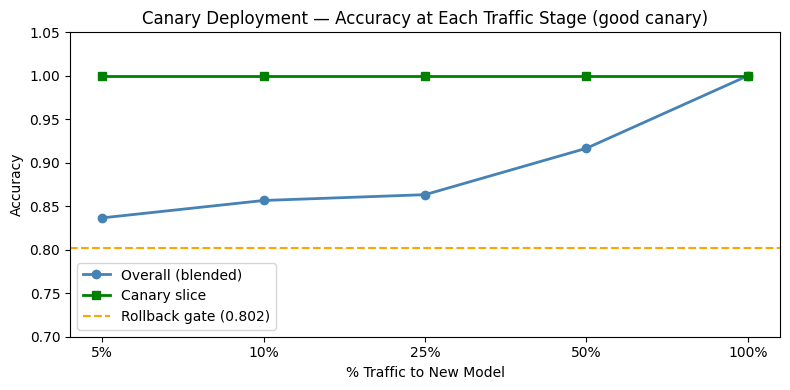

In [6]:
# Visualise scenario 1 (the good canary): accuracy at every traffic stage.
stages = [f"{int(s['stage']*100)}%" for s in stage_results]
overall = [s["overall"] for s in stage_results]
new_slice = [s["new_slice"] for s in stage_results]

plt.figure(figsize=(8, 4))
# Blended accuracy rises as more traffic reaches the better model
plt.plot(stages, overall, marker="o", color="steelblue", linewidth=2, label="Overall (blended)")
# The canary slice itself is what the gate watches
plt.plot(stages, new_slice, marker="s", color="green", linewidth=2, label="Canary slice")
# The rollback line: old-model baseline minus the tolerance margin
plt.axhline(gate_line, color="orange", linestyle="--", label=f"Rollback gate ({gate_line:.3f})")
plt.title("Canary Deployment — Accuracy at Each Traffic Stage (good canary)")
plt.xlabel("% Traffic to New Model")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/canary_stages.png", dpi=72)
plt.show()


## 👁️ See it — what the two decisions were really made on

Two decisions have been taken above: the A/B test declared model B the winner, and the canary promoted it stage by stage. Both were correct. Both were also made on evidence narrower than the printed numbers suggest, and the two panels below show where.

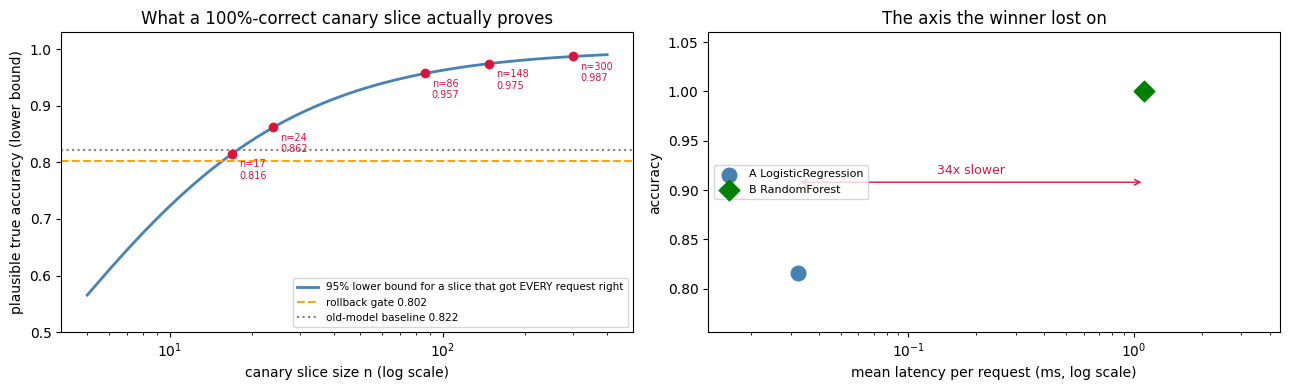

  canary slice n    95% lower bound on a perfect slice
              17                                 0.816
              24                                 0.862
              86                                 0.957
             148                                 0.975
             300                                 0.987

gate = 0.802, old-model baseline = 0.822
accuracy A 0.8159 vs B 1.0000; mean latency A 0.0323 ms vs B 1.1125 ms (34x)


In [7]:
# WHAT: left — how much a PERFECT canary slice proves as a function of its size,
# using a Wilson 95% interval; right — the two models on accuracy and latency.
# WHY: "canary_slice = 1.000" and "B is more accurate" are both true statements
# that hide their own uncertainty and their own cost.
def wilson_lower_bound(successes: int, n: int, z: float = 1.96) -> float:
    """Lower end of the 95% Wilson interval — the pessimistic reading of k/n."""
    if n == 0:
        return float("nan")
    p = successes / n
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = (z / (1 + z * z / n)) * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return centre - half


baseline_acc = float(model_a.score(X_test, y_test))     # the champion the gate compares to
slice_sizes = [s["n_new"] for s in stage_results]       # the actual canary slices used above

n_grid = np.arange(5, 401)
lower_curve = [wilson_lower_bound(n, n) for n in n_grid]   # perfect slice: k = n

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(n_grid, lower_curve, color="steelblue", lw=2,
        label="95% lower bound for a slice that got EVERY request right")
ax.axhline(gate_line, color="orange", linestyle="--", label=f"rollback gate {gate_line:.3f}")
ax.axhline(baseline_acc, color="grey", linestyle=":", label=f"old-model baseline {baseline_acc:.3f}")
for n in slice_sizes:
    ax.plot([n], [wilson_lower_bound(n, n)], "o", color="crimson")
    ax.annotate(f"n={n}\n{wilson_lower_bound(n, n):.3f}", (n, wilson_lower_bound(n, n)),
                textcoords="offset points", xytext=(5, -18), fontsize=7, color="crimson")
ax.set_xscale("log")
ax.set_xlabel("canary slice size n (log scale)")
ax.set_ylabel("plausible true accuracy (lower bound)")
ax.set_title("What a 100%-correct canary slice actually proves")
ax.set_ylim(0.5, 1.03)
ax.legend(fontsize=7.5, loc="lower right")

ax2 = axes[1]
lat_a, lat_b = summary_a["Mean Latency (ms)"], summary_b["Mean Latency (ms)"]
acc_a, acc_b = summary_a["Accuracy"], summary_b["Accuracy"]
ax2.scatter([lat_a], [acc_a], s=110, color="steelblue", marker="o", label="A LogisticRegression")
ax2.scatter([lat_b], [acc_b], s=110, color="green", marker="D", label="B RandomForest")
ax2.annotate("", xy=(lat_b, (acc_a + acc_b) / 2), xytext=(lat_a, (acc_a + acc_b) / 2),
             arrowprops=dict(arrowstyle="<->", color="crimson"))
ax2.text(np.sqrt(lat_a * lat_b), (acc_a + acc_b) / 2 + 0.008,
         f"{lat_b / lat_a:.0f}x slower", color="crimson", ha="center", fontsize=9)
ax2.set_xscale("log")
ax2.set_xlim(lat_a * 0.4, lat_b * 4)
ax2.set_ylim(min(acc_a, acc_b) - 0.06, 1.06)
ax2.set_xlabel("mean latency per request (ms, log scale)")
ax2.set_ylabel("accuracy")
ax2.set_title("The axis the winner lost on")
ax2.legend(fontsize=8, loc="center left")

plt.tight_layout()
plt.savefig("/tmp/ab_canary_evidence.png", dpi=72)
plt.show()

print(f"{'canary slice n':>16}{'95% lower bound on a perfect slice':>38}")
for n in slice_sizes:
    print(f"{n:>16}{wilson_lower_bound(n, n):>38.3f}")
print(f"\ngate = {gate_line:.3f}, old-model baseline = {baseline_acc:.3f}")
print(f"accuracy A {acc_a:.4f} vs B {acc_b:.4f}; "
      f"mean latency A {lat_a:.4f} ms vs B {lat_b:.4f} ms ({lat_b / lat_a:.0f}x)")

**Read the left panel.** The blue curve answers one question: if a canary slice of size *n* gets **every** request right, how bad could its true accuracy still plausibly be? At the first gate — `n = 17` — the answer is about **0.82**. That is barely above the rollback gate (orange) and essentially level with the old model's own accuracy (grey dotted). In other words, a replacement model that is *no better than the one it replaces* would sail through that gate on a perfect 17-for-17 whenever luck was mildly on its side. Only by the later stages, where the slice reaches 148 and 300 requests, does a perfect slice actually rule out a mediocre model.

**Read the right panel.** The same two models, plotted on the axis the summary table reported but the decision ignored. B wins the y axis outright. On the x axis — note it is logarithmic — B is **tens of times** slower per request; the pink arrow is labelled with the factor measured on this run, and because latency is wall-clock that number moves a little every execution. Nothing in the z-test, the p-value, or the canary gate looked at that axis at all.

**What it proves.** A promotion rule is only as good as the evidence it consumes. Gate on percentages of traffic and you will judge early stages on a handful of requests; gate on accuracy alone and you will promote a model that is right more often and answers far more slowly. **Size your canary stages by the number of observations the decision needs, and write the latency budget into the gate before the rollout, not after the first complaint.**

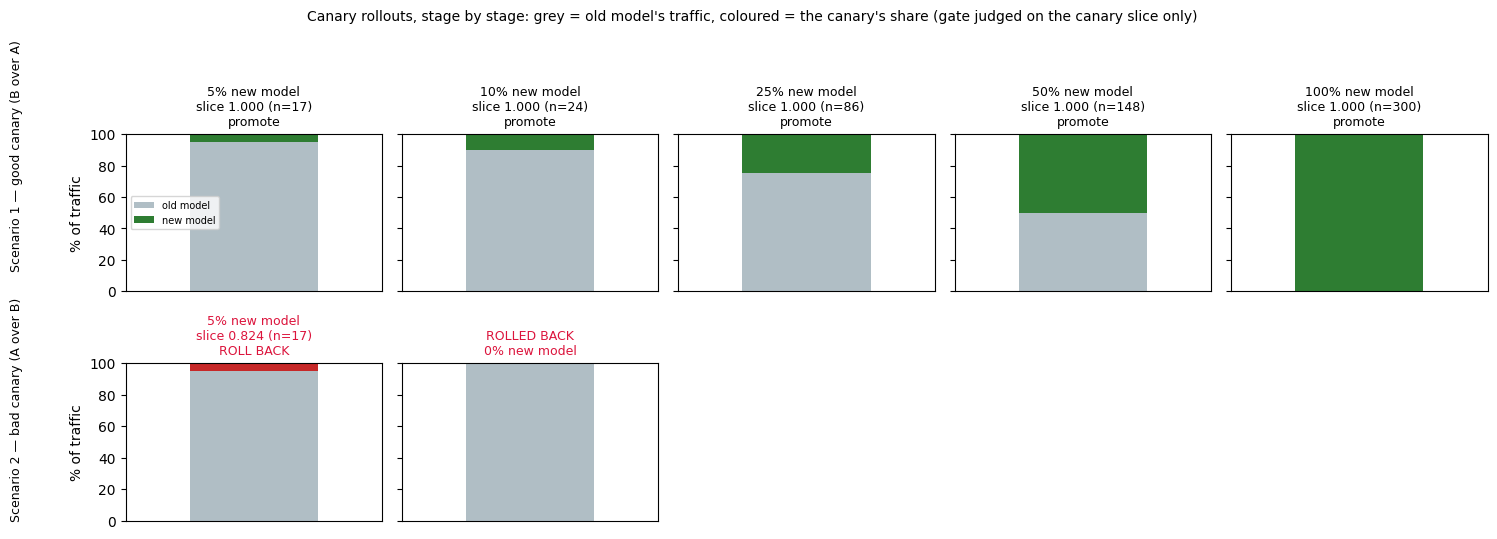

good canary reached 5 stages; final traffic share 100% (gate 0.802)
bad canary reached 1 stage(s); slice accuracy 0.824 < gate 0.980 -> rolled back with 5% of users exposed


In [8]:
# WHAT: storyboard the two rollouts — traffic split, slice verdict and outcome
# at every stage the canary actually reached.
# WHY: the line chart above plots accuracy; this shows the thing that is really
# moving during a canary, which is the fraction of your users exposed to the risk.
scenarios = [("Scenario 1 — good canary (B over A)", stage_results, gate_line, False),
             ("Scenario 2 — bad canary (A over B)", bad_results, bad_gate, True)]

fig, axes = plt.subplots(2, 5, figsize=(15, 5.4))
for row, (title, results, gate, rolled_back) in enumerate(scenarios):
    # One panel per stage the rollout reached, plus a final panel if it was rolled back.
    panels = list(results) + ([{"stage": 0.0, "new_slice": float("nan"), "n_new": 0}]
                              if rolled_back else [])
    for col in range(5):
        ax = axes[row][col]
        if col >= len(panels):
            ax.axis("off")
            continue
        stage = panels[col]
        new_pct = stage["stage"] * 100
        passed = (not np.isnan(stage["new_slice"])) and stage["new_slice"] >= gate
        ax.bar([0], [100 - new_pct], width=0.6, color="#b0bec5", label="old model")
        ax.bar([0], [new_pct], width=0.6, bottom=100 - new_pct,
               color=("#2e7d32" if passed else "#c62828"), label="new model")
        ax.set_ylim(0, 100); ax.set_xlim(-0.6, 0.6); ax.set_xticks([])
        ax.set_ylabel("% of traffic" if col == 0 else "")
        if col > 0:
            ax.set_yticklabels([])
        if np.isnan(stage["new_slice"]):
            ax.set_title("ROLLED BACK\n0% new model", fontsize=9, color="crimson")
        else:
            ax.set_title(f"{new_pct:.0f}% new model\nslice {stage['new_slice']:.3f} "
                         f"(n={stage['n_new']})\n{'promote' if passed else 'ROLL BACK'}",
                         fontsize=9, color=("black" if passed else "crimson"))
    # Row label in the left margin so it cannot collide with the panel titles.
    fig.text(0.005, 0.72 - 0.47 * row, title, rotation=90, va="center",
             ha="left", fontsize=9)
axes[0][0].legend(fontsize=7, loc="center left")
fig.suptitle("Canary rollouts, stage by stage: grey = old model's traffic, "
             "coloured = the canary's share (gate judged on the canary slice only)",
             fontsize=10, y=0.99)
plt.tight_layout(rect=[0.035, 0, 1, 0.93])
plt.savefig("/tmp/canary_storyboard.png", dpi=72)
plt.show()

print(f"good canary reached {len(stage_results)} stages; "
      f"final traffic share {stage_results[-1]['stage'] * 100:.0f}% "
      f"(gate {gate_line:.3f})")
print(f"bad canary reached {len(bad_results)} stage(s); "
      f"slice accuracy {bad_results[-1]['new_slice']:.3f} < gate {bad_gate:.3f} "
      f"-> rolled back with {bad_results[-1]['stage'] * 100:.0f}% of users exposed")

**Read the storyboard.** The top row is the successful rollout: the coloured band grows 5% → 10% → 25% → 50% → 100% and the title of each panel carries the only number the gate looked at, the canary slice's own accuracy and the number of requests it was computed from. The bottom row is the failure, and it has only two panels because the rollout never reached a third: at the very first stage the weak model's slice scored **0.824** against a gate of **0.980**, so the second panel is the aftermath — traffic back to 0% new model, all grey — and the three stages that would have followed never happen. That is why the bottom row stops short of the top one.

**What it proves.** The grey band is the point of the whole technique. In the bad scenario the new model was catastrophically worse, yet only **5% of requests** ever reached it, and the *blended* accuracy those users and everyone else saw stayed at 0.990 — which is exactly why you must never gate on the blended number: at 5% traffic it is 95% old model and it cannot move enough to fail. The gate has to read the canary's own slice, and the canary's own slice is small, which is the tension the left panel of the previous figure measured.

And notice what a canary does **not** do: 5% of users still received the bad model. For a recommendation that is an acceptable price. For a payment declined or a dose calculated, 5% is 5%, and the right answer is a shadow deployment — run the new model, log its answers, serve the old one's.

## 💬 Discuss

Three results from the A/B run are in tension. Model B is **decisively** more accurate (1.0000 vs 0.8159, z = 9.819, p ≈ 0). Model B is also **tens of times slower** per request — read the exact pair off the summary table above (around 1.2 ms against 0.03 ms; these are wall-clock timings, so they shift slightly on every run). And in the canary run, the first gate promoted on a canary slice of **n = 17 requests**.

1. B wins on accuracy and loses on latency by a factor of tens. At what latency does the accuracy gain stop being worth it? Answer it twice — once for a fraud check at checkout, once for a nightly churn score — and notice that the model comparison did not change, only the context.
2. Seventeen requests. Compute roughly what accuracy range is consistent with `canary_slice = 1.000` at n = 17, then decide whether that gate should have promoted. What is the minimum sample you would require before allowing a stage to advance, and what does waiting cost you?
3. All three rollback scenarios returned `True`, including one triggered by an error-rate difference of **0.008 against a 0.005 threshold**. Is that threshold too tight? Argue it as the engineer who will be woken up by the rollback, then as the customer in the 0.8%.

## Section 6 — Rollback Criteria

Define explicit, measurable conditions that trigger an automatic rollback.

In [9]:
# WHAT: codify the rollback decision — error-rate delta and latency conditions
# with three worked scenarios.
# WHY: rollback criteria must be written BEFORE the rollout; at 3 a.m. nobody
# should be debating thresholds — the function already knows.
def should_rollback(
    old_error_rate: float,
    new_error_rate: float,
    error_rate_delta_threshold: float = 0.005,  # 0.5 percentage points
    new_p99_latency_ms: float = 0.0,
    latency_threshold_ms: float = 500.0,
) -> Tuple[bool, str]:
    """
    Returns (True, reason) if rollback criteria are met, else (False, 'OK').
    """
    if new_error_rate > old_error_rate + error_rate_delta_threshold:
        delta = new_error_rate - old_error_rate
        return True, (
            f"New model error rate {new_error_rate:.3f} exceeds old model "
            f"by {delta:.3f} (threshold={error_rate_delta_threshold})"
        )
    if new_p99_latency_ms > latency_threshold_ms:
        return True, (
            f"New model p99 latency {new_p99_latency_ms:.1f}ms > threshold {latency_threshold_ms:.1f}ms"
        )
    return False, "OK — no rollback needed"


# Below the delta threshold: tolerated. Scenario 2 crosses it; 3 fails on latency.
# Scenario 1: New model is slightly worse on error rate
rollback, reason = should_rollback(old_error_rate=0.05, new_error_rate=0.058)
print(f"Scenario 1 — Rollback? {rollback}: {reason}")

# Scenario 2: New model error rate exceeds threshold
rollback, reason = should_rollback(old_error_rate=0.05, new_error_rate=0.062)
print(f"Scenario 2 — Rollback? {rollback}: {reason}")

# Scenario 3: New model is accurate but too slow
rollback, reason = should_rollback(old_error_rate=0.05, new_error_rate=0.04, new_p99_latency_ms=600)
print(f"Scenario 3 — Rollback? {rollback}: {reason}")

Scenario 1 — Rollback? True: New model error rate 0.058 exceeds old model by 0.008 (threshold=0.005)
Scenario 2 — Rollback? True: New model error rate 0.062 exceeds old model by 0.012 (threshold=0.005)
Scenario 3 — Rollback? True: New model p99 latency 600.0ms > threshold 500.0ms


## Summary

| Strategy | How it works | When to use |
|---|---|---|
| **A/B test** | Split traffic between A and B; collect metrics; run statistical test | When you want to compare two models with statistical confidence |
| **Canary** | Gradually shift traffic 5% → 100%, gating each stage on the canary slice's own metrics vs the old baseline; roll back on degradation | When you want to limit blast radius of a bad release |

Key principle: **never make promotion automatic without a statistical gate**. The z-test (or chi-squared test) tells you whether observed differences are real or sampling noise.

## Self-Check (answer before scrolling back up)

1. **What sample size do you need before an A/B test is statistically valid?**  
   It depends on the effect size you want to detect and your desired statistical power (typically 80%) and significance level (typically 5%). For a typical ML model with 95% accuracy trying to detect a 1-2% improvement, you usually need several hundred requests per variant minimum. Use a power calculator with your baseline conversion rate and expected delta to get the exact number.

2. **What is the difference between an A/B test and a canary deployment?**  
   An A/B test is primarily a measurement tool — you run both models simultaneously and compare outcomes statistically. A canary deployment is primarily a risk management tool — you shift traffic gradually and roll back if anything goes wrong. They are complementary: you might run an A/B test at the 10% canary stage to validate the decision before promoting to 100%.

3. **If your canary deployment shows higher accuracy but also higher latency, what do you do?**  
   Do not promote automatically. Decide based on your SLOs and business priorities: if the latency exceeds your p99 SLO, roll back and investigate the latency issue separately (batching, model compression, hardware upgrade). If the latency is within SLO but higher than before, weigh the accuracy gain against the latency cost for your specific use case.

## ⚠️ Where this breaks

- **A canary slice is small by construction, which is exactly when statistics are weakest.** Our 5% stage decided on **17 requests**. A slice that small cannot distinguish a great model from a lucky one, so early gates mostly detect *catastrophic* failure — crashes, timeouts, empty responses — not quality regressions. Size your stages by the number of observations you need, not by round percentages.
- **A/B testing needs an outcome, and often there isn't one yet.** We compared accuracy because this simulation knows the true labels. In production, the label for a fraud decision arrives in weeks and the label for a loan decision in years. Where labels are slow, you are reduced to proxies — engagement, override rate, complaint rate — and every proxy can be gamed by the model you are testing.
- **Random assignment per request is usually wrong.** Our router splits on each request independently, so one user can be served by A and B alternately. That contaminates any user-level metric and makes the experience inconsistent. Assign by a hash of the user ID so a given user stays in one arm.
- **The z-test assumes independent observations.** Requests from the same user, the same session, or the same automated client are not independent, and treating them as such inflates your sample size and shrinks your p-value. A p ≈ 0 from correlated traffic is a p-value about your assumptions, not about your model.
- **The assumption that must hold:** the two arms differ only in the model. Deploy B on newer hardware, in a different region, or after a cache has warmed, and you are measuring the infrastructure. This is also why the canary's traffic must be representative — a canary that only receives internal or low-value traffic proves nothing about the traffic you care about.
- **Canary limits blast radius; it does not eliminate it.** Five percent of users still received the change. For a recommendation model that is a fair price. For an irreversible decision — a payment declined, a message sent, a dose calculated — 5% of users is 5% of users, and a shadow deployment (run the new model, log its answers, serve the old one) is the cheaper, safer alternative.
- **When neither is worth it.** For a model retrained quarterly and reviewed by a human before its outputs act, an offline comparison on a fair held-out set plus a sign-off is proportionate. A/B infrastructure, traffic routing and sequential gating are the price of shipping frequently to live users — pay it when you actually do that.

## 📚 References

1. Kohavi, R., Longbotham, R., Sommerfield, D., & Henne, R. M. (2009). *Controlled Experiments on the Web: Survey and Practical Guide*. Data Mining and Knowledge Discovery 18(1). <https://doi.org/10.1007/s10618-008-0114-1>
2. Tang, D., Agarwal, A., O'Brien, D., & Meyer, M. (2010). *Overlapping Experiment Infrastructure: More, Better, Faster Experimentation*. KDD. <https://research.google/pubs/overlapping-experiment-infrastructure-more-better-faster-experimentation/>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
